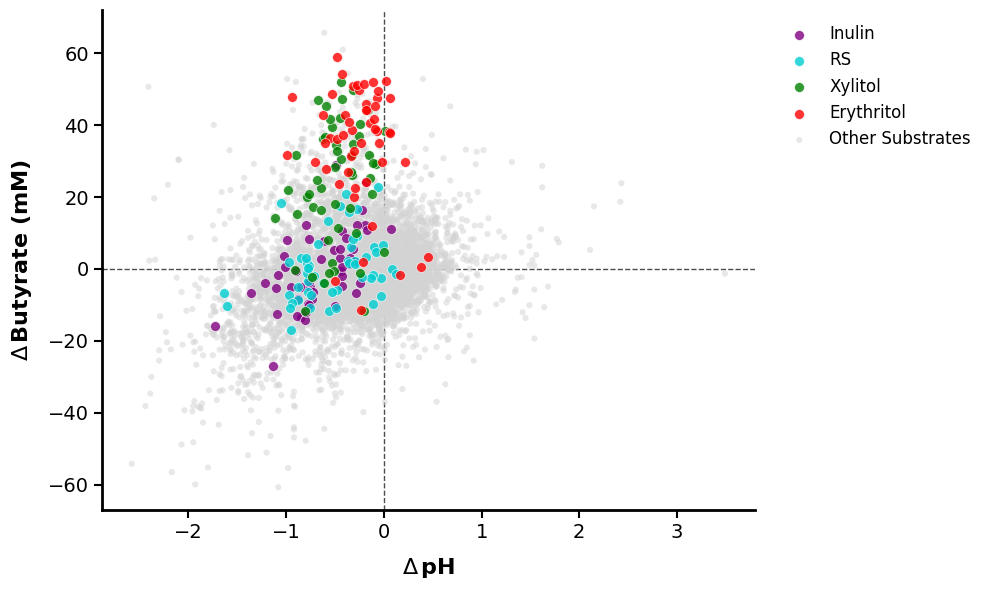

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

# Suppress warnings for clean output
warnings.filterwarnings('ignore')

# =============================================================================
# 1. Publication-Quality Visualization Settings (Nature Portfolio)
# =============================================================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
DPI_SETTING = 600

# =============================================================================
# 2. Robust Data Loading & Strict Exclusion Rules
# =============================================================================
def clean_and_convert_to_nan(df, cols):
    """
    Strictly converts non-numeric values (e.g., 'Undetermined', '-', 'nan') to np.nan.
    Zero-imputation is completely avoided to maintain scientific integrity.
    """
    for col in cols:
        df[col] = df[col].astype(str).replace(['Undetermined', '-', 'nan', '#VALUE!', ''], np.nan)
        df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

# Load raw datasets
df_ph = pd.read_csv('pH.csv')
df_buty = pd.read_csv('Butyrate(mM).csv')

# Extract donor columns
donor_cols = [c for c in df_ph.columns if c.startswith('HS-')]

# Apply data cleaning
df_ph = clean_and_convert_to_nan(df_ph, donor_cols)
df_buty = clean_and_convert_to_nan(df_buty, donor_cols)

# =============================================================================
# 3. Calculate Delta (Substrate - Control)
# =============================================================================
ctrl_ph = df_ph[df_ph['KULFFI'].str.strip() == 'Control'][donor_cols].iloc[0]
ctrl_buty = df_buty[df_buty['KULFFI'].str.strip() == 'Control'][donor_cols].iloc[0]

records = []

for idx, row in df_ph.iterrows():
    kulffi = str(row['KULFFI']).strip()
    if kulffi == 'Control':
        continue

    sub_ph = row[donor_cols]
    buty_rows = df_buty[df_buty['KULFFI'].str.strip() == kulffi]

    if buty_rows.empty:
        continue

    sub_buty = buty_rows[donor_cols].iloc[0]

    delta_ph = sub_ph - ctrl_ph
    delta_buty = sub_buty - ctrl_buty

    # Enforce strict pairwise exclusion for valid correlation plotting
    for donor in donor_cols:
        if pd.notna(delta_ph[donor]) and pd.notna(delta_buty[donor]):
            records.append({
                'KULFFI': kulffi,
                'Donor': donor,
                'Delta_pH': delta_ph[donor],
                'Delta_Butyrate': delta_buty[donor]
            })

df_plot = pd.DataFrame(records)

# =============================================================================
# 4. Plotting Universal pH Cliff (Scatter for all donors x substrates)
# =============================================================================
fig, ax = plt.subplots(figsize=(10, 6))

target_substrates = ['Inulin', 'Resistant starch', 'Xylitol', 'Erythritol']

# Map data names to strictly requested legend display names
display_names = {
    'Inulin': 'Inulin',
    'Resistant starch': 'RS',
    'Xylitol': 'Xylitol',
    'Erythritol': 'Erythritol'
}

# Colors perfectly synchronized with @5a.ipynb base_colors
highlights = {
    'Inulin': '#800080',             # Purple
    'Resistant starch': '#00CED1',   # Turquoise
    'Xylitol': '#008000',            # Green
    'Erythritol': '#FF0000'          # Red
}

# 1. Plot 'Target Substrates' FIRST to enforce legend order
for name, color in highlights.items():
    df_h = df_plot[df_plot['KULFFI'] == name]
    ax.scatter(df_h['Delta_pH'], df_h['Delta_Butyrate'],
               color=color, alpha=0.8, s=50, edgecolors='white', linewidth=0.5,
               label=display_names[name], zorder=3)

# 2. Plot 'Other Substrates' LAST so it appears at the bottom of the legend
df_other = df_plot[~df_plot['KULFFI'].isin(target_substrates)]
ax.scatter(df_other['Delta_pH'], df_other['Delta_Butyrate'],
           color='lightgray', alpha=0.5, s=20, edgecolors='none',
           label='Other Substrates', zorder=1)

# Reference Lines (Zero-crossing)
ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.7, zorder=0)
ax.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.7, zorder=0)

# LaTeX thin space '\,' applied securely inside math mode
ax.set_xlabel(r'$\Delta\,$pH', fontsize=16, fontweight='bold', labelpad=10)
ax.set_ylabel(r'$\Delta\,$Butyrate (mM)', fontsize=16, fontweight='bold', labelpad=10)

# Tick parameters
ax.tick_params(axis='both', labelsize=14, width=1.5, length=6)

# Frame adjustments
for spine in ['left', 'bottom']:
    ax.spines[spine].set_linewidth(2.0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Render legend reflecting the exact plotting order
ax.legend(frameon=False, fontsize=12, loc='upper left', bbox_to_anchor=(1.02, 1))

plt.tight_layout()

# Export to PDF
output_file = 'Figure_6c.pdf'
plt.savefig(output_file, dpi=DPI_SETTING, bbox_inches='tight')
plt.show()